In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

n = 1500

df = pd.DataFrame({
    "Employee_ID": range(1001, 1001 + n),

    "Department": np.random.choice(
        ["Engineering", "Sales", "Marketing",
         "HR", "Finance", "Customer Support"],
        n
    ),

    "Job_Level": np.random.choice(
        ["Entry", "Mid", "Senior", "Manager"],
        n,
        p=[0.30, 0.35, 0.25, 0.10]
    ),

    "Age": np.random.randint(21, 60, n),

    "Years_At_Company": np.random.randint(
        0, 16, n
    ),

    "Monthly_Income": np.random.randint(
        30000, 160000, n
    ),

    "Job_Satisfaction": np.random.randint(
        1, 6, n
    ),

    "Work_Life_Balance": np.random.randint(
        1, 6, n
    ),

    "Management_Support": np.random.randint(
        1, 6, n
    ),

    "Recognition": np.random.randint(
        1, 6, n
    ),

    "Career_Growth": np.random.randint(
        1, 6, n
    ),

    "Workload": np.random.randint(
        1, 6, n
    ),

    "Working_Hours": np.random.randint(
        35, 65, n
    ),

    "Overtime": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.35, 0.65]
    ),

    "Remote_Work": np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.45, 0.55]
    ),

    "Team_Collaboration": np.random.randint(
        1, 6, n
    ),

    "Training_Opportunities": np.random.randint(
        1, 6, n
    )
})

print("Synthetic employee engagement dataset created!")
print("Shape:", df.shape)

df.head()

Synthetic employee engagement dataset created!
Shape: (1500, 17)


,Employee_ID,Department,Job_Level,Age,Years_At_Company,Monthly_Income,Job_Satisfaction,Work_Life_Balance,Management_Support,Recognition,Career_Growth,Workload,Working_Hours,Overtime,Remote_Work,Team_Collaboration,Training_Opportunities
0,1001,HR,Entry,43,2,124503,4,1,3,5,3,3,49,Yes,Yes,3,1
1,1002,Finance,Entry,35,11,32159,3,2,4,3,5,4,40,No,No,5,4
2,1003,Marketing,Mid,47,8,78940,1,3,5,2,5,3,56,No,No,2,4
3,1004,Finance,Senior,31,4,109436,2,5,4,5,2,5,46,No,Yes,1,3
4,1005,Finance,Manager,37,11,106976,1,3,1,1,2,5,63,No,Yes,5,3


In [3]:
df["Engagement_Score"] = (
    df["Job_Satisfaction"] +
    df["Management_Support"] +
    df["Recognition"] +
    df["Career_Growth"] +
    df["Team_Collaboration"] +
    df["Training_Opportunities"]
)

# Convert into 0–100 scale
df["Engagement_Score"] = (
    df["Engagement_Score"] / 30 * 100
).round(2)

df[[
    "Employee_ID",
    "Engagement_Score"
]].head(10)

,Employee_ID,Engagement_Score
0,1001,63.33
1,1002,80.00
2,1003,63.33
3,1004,56.67
4,1005,43.33
5,1006,63.33
6,1007,63.33
7,1008,56.67
8,1009,56.67
9,1010,83.33


In [4]:
df["Burnout_Score"] = (
    (df["Workload"] * 15) +
    ((df["Working_Hours"] - 35) / 30 * 20) +
    ((df["Overtime"] == "Yes").astype(int) * 20) +
    ((6 - df["Work_Life_Balance"]) * 10)
)

df["Burnout_Score"] = df["Burnout_Score"].clip(
    0, 100
).round(2)

df[[
    "Employee_ID",
    "Burnout_Score"
]].head(10)

,Employee_ID,Burnout_Score
0,1001,100.00
1,1002,100.00
2,1003,89.00
3,1004,92.33
4,1005,100.00
5,1006,76.33
6,1007,100.00
7,1008,97.67
8,1009,100.00
9,1010,94.33


In [5]:
df["Burnout_Level"] = pd.cut(
    df["Burnout_Score"],
    bins=[-1, 30, 60, 100],
    labels=[
        "Low Burnout",
        "Medium Burnout",
        "High Burnout"
    ]
)

df["Engagement_Level"] = pd.cut(
    df["Engagement_Score"],
    bins=[-1, 40, 70, 100],
    labels=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ]
)

df[
    [
        "Employee_ID",
        "Engagement_Score",
        "Engagement_Level",
        "Burnout_Score",
        "Burnout_Level"
    ]
].head(15)

,Employee_ID,Engagement_Score,Engagement_Level,Burnout_Score,Burnout_Level
0,1001,63.33,Medium Engagement,100.00,High Burnout
1,1002,80.00,High Engagement,100.00,High Burnout
2,1003,63.33,Medium Engagement,89.00,High Burnout
3,1004,56.67,Medium Engagement,92.33,High Burnout
4,1005,43.33,Medium Engagement,100.00,High Burnout
5,1006,63.33,Medium Engagement,76.33,High Burnout
6,1007,63.33,Medium Engagement,100.00,High Burnout
7,1008,56.67,Medium Engagement,97.67,High Burnout
8,1009,56.67,Medium Engagement,100.00,High Burnout
9,1010,83.33,High Engagement,94.33,High Burnout


In [6]:
print("Total Employees:", len(df))
print("Total Columns:", len(df.columns))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Total Employees: 1500
Total Columns: 21

Missing Values:
Employee_ID               0
Department                0
Job_Level                 0
Age                       0
Years_At_Company          0
Monthly_Income            0
Job_Satisfaction          0
Work_Life_Balance         0
Management_Support        0
Recognition               0
Career_Growth             0
Workload                  0
Working_Hours             0
Overtime                  0
Remote_Work               0
Team_Collaboration        0
Training_Opportunities    0
Engagement_Score          0
Burnout_Score             0
Burnout_Level             0
Engagement_Level          0
dtype: int64

Duplicate Records:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Employee_ID             1500 non-null   int64   
 1   Department              

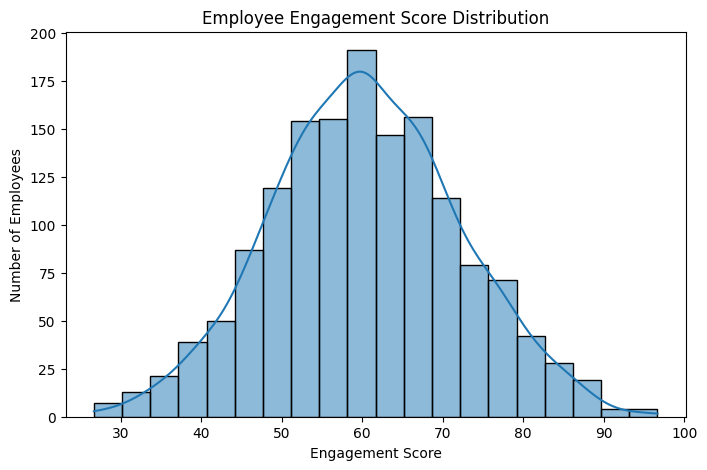

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Engagement_Score"],
    bins=20,
    kde=True
)

plt.title("Employee Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Employees")

plt.show()

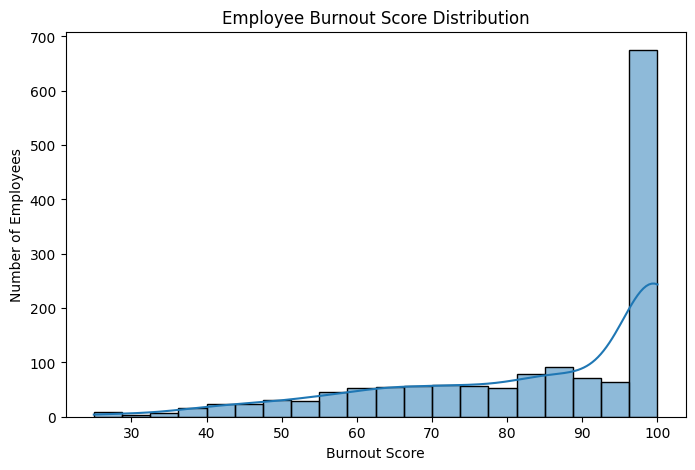

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Burnout_Score"],
    bins=20,
    kde=True
)

plt.title("Employee Burnout Score Distribution")
plt.xlabel("Burnout Score")
plt.ylabel("Number of Employees")

plt.show()

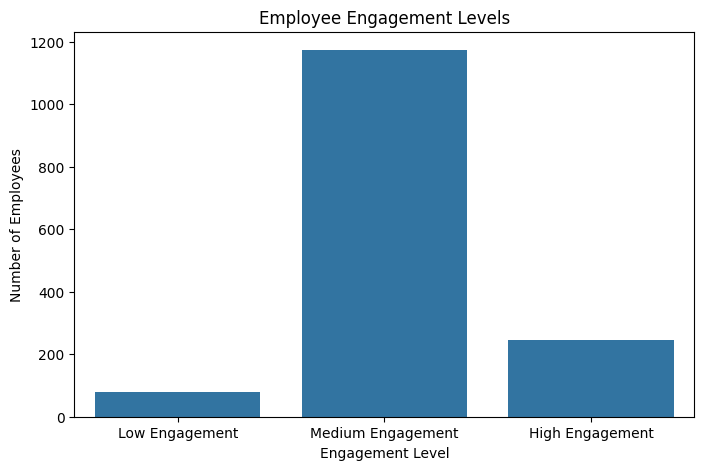

Engagement_Level
Medium Engagement    1173
High Engagement       247
Low Engagement         80
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Engagement_Level",
    order=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ]
)

plt.title("Employee Engagement Levels")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Employees")

plt.show()

print(df["Engagement_Level"].value_counts())

In [10]:
department_engagement = (
    df.groupby("Department")["Engagement_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(
    department_engagement.round(2)
)

Department
HR                  61.40
Customer Support    61.02
Finance             60.26
Engineering         60.16
Marketing           59.92
Sales               59.64
Name: Engagement_Score, dtype: float64


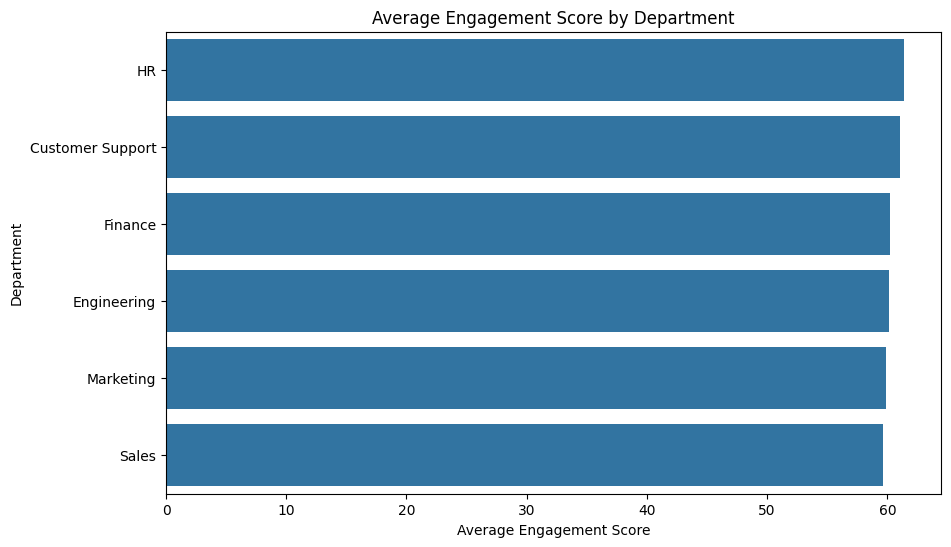

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=department_engagement.values,
    y=department_engagement.index
)

plt.title("Average Engagement Score by Department")
plt.xlabel("Average Engagement Score")
plt.ylabel("Department")

plt.show()

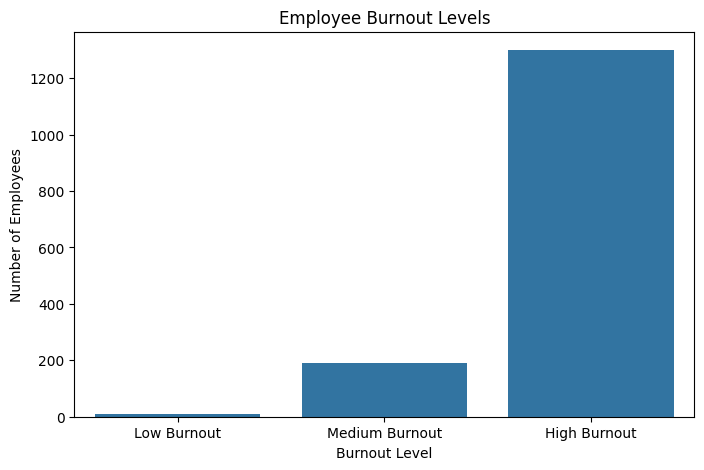

Burnout_Level
High Burnout      1300
Medium Burnout     190
Low Burnout         10
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Burnout_Level",
    order=[
        "Low Burnout",
        "Medium Burnout",
        "High Burnout"
    ]
)

plt.title("Employee Burnout Levels")
plt.xlabel("Burnout Level")
plt.ylabel("Number of Employees")

plt.show()

print(df["Burnout_Level"].value_counts())

In [13]:
department_burnout = (
    df.groupby("Department")["Burnout_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(
    department_burnout.round(2)
)

Department
Customer Support    85.27
Engineering         85.24
Finance             84.44
Marketing           84.32
HR                  83.98
Sales               82.76
Name: Burnout_Score, dtype: float64


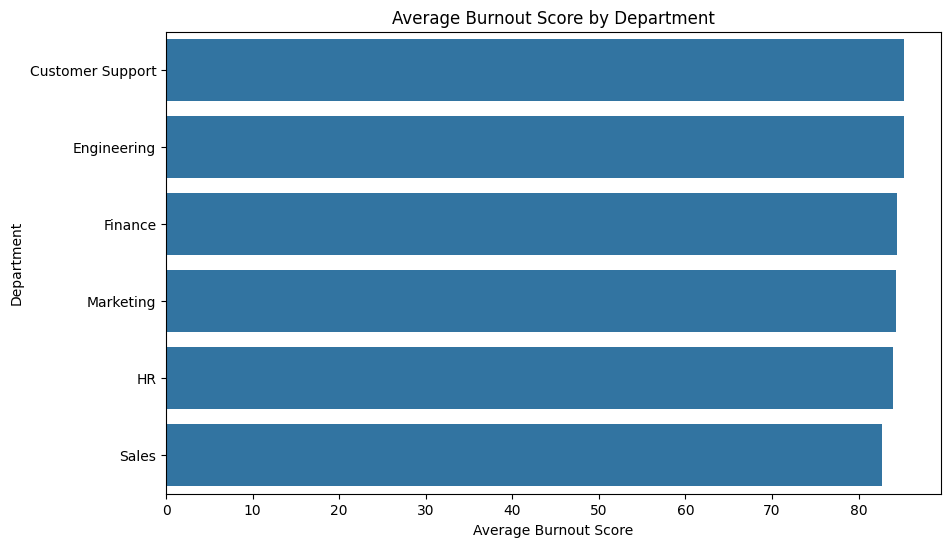

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=department_burnout.values,
    y=department_burnout.index
)

plt.title("Average Burnout Score by Department")
plt.xlabel("Average Burnout Score")
plt.ylabel("Department")

plt.show()

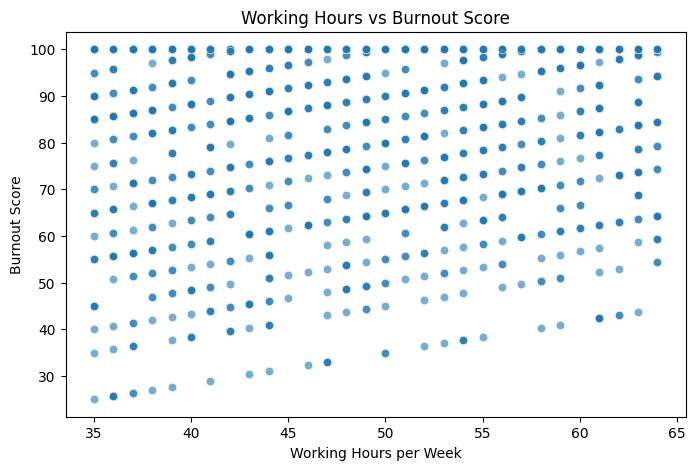

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Working_Hours",
    y="Burnout_Score",
    alpha=0.6
)

plt.title("Working Hours vs Burnout Score")
plt.xlabel("Working Hours per Week")
plt.ylabel("Burnout Score")

plt.show()

In [16]:
overtime_burnout = (
    df.groupby("Overtime")["Burnout_Score"]
    .mean()
)

print(overtime_burnout.round(2))

Overtime
No     80.48
Yes    91.51
Name: Burnout_Score, dtype: float64


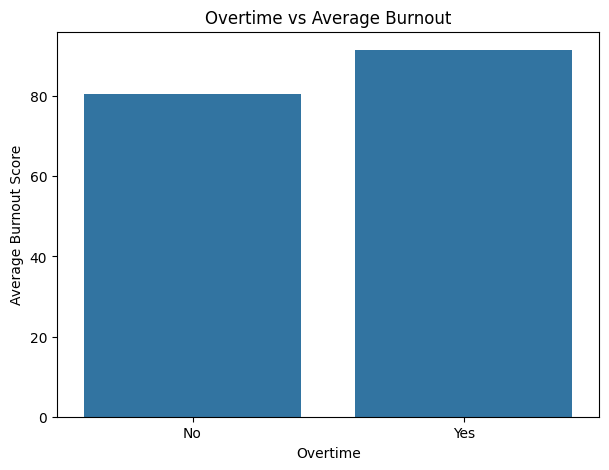

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=overtime_burnout.index,
    y=overtime_burnout.values
)

plt.title("Overtime vs Average Burnout")
plt.xlabel("Overtime")
plt.ylabel("Average Burnout Score")

plt.show()

In [18]:
satisfaction_burnout = (
    df.groupby("Job_Satisfaction")["Burnout_Score"]
    .mean()
)

print(
    satisfaction_burnout.round(2)
)

Job_Satisfaction
1    85.37
2    83.60
3    84.36
4    83.76
5    84.76
Name: Burnout_Score, dtype: float64


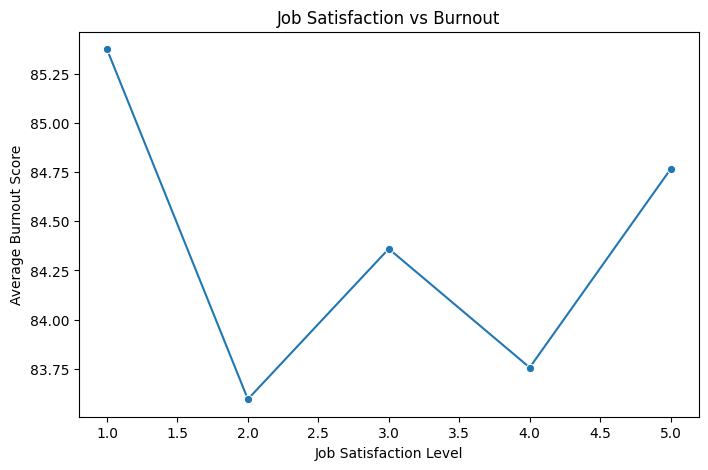

In [19]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=satisfaction_burnout.index,
    y=satisfaction_burnout.values,
    marker="o"
)

plt.title("Job Satisfaction vs Burnout")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Average Burnout Score")

plt.show()

In [20]:
worklife_burnout = (
    df.groupby("Work_Life_Balance")["Burnout_Score"]
    .mean()
)

print(
    worklife_burnout.round(2)
)

Work_Life_Balance
1    94.75
2    89.98
3    85.98
4    78.02
5    70.12
Name: Burnout_Score, dtype: float64


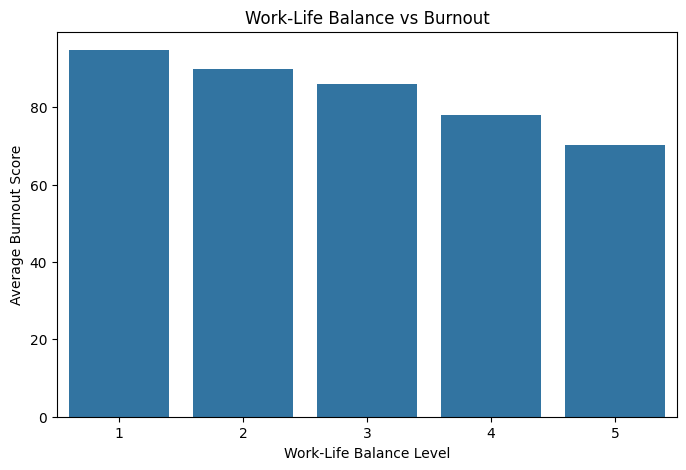

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=worklife_burnout.index,
    y=worklife_burnout.values
)

plt.title("Work-Life Balance vs Burnout")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Average Burnout Score")

plt.show()

In [22]:
management_analysis = (
    df.groupby("Management_Support")[
        "Engagement_Score"
    ].mean()
)

print(
    management_analysis.round(2)
)

Management_Support
1    53.48
2    57.23
3    61.17
4    63.08
5    65.80
Name: Engagement_Score, dtype: float64


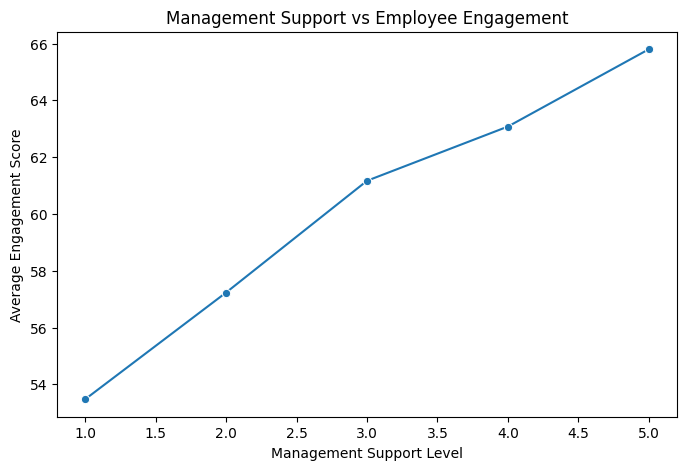

In [23]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=management_analysis.index,
    y=management_analysis.values,
    marker="o"
)

plt.title("Management Support vs Employee Engagement")
plt.xlabel("Management Support Level")
plt.ylabel("Average Engagement Score")

plt.show()

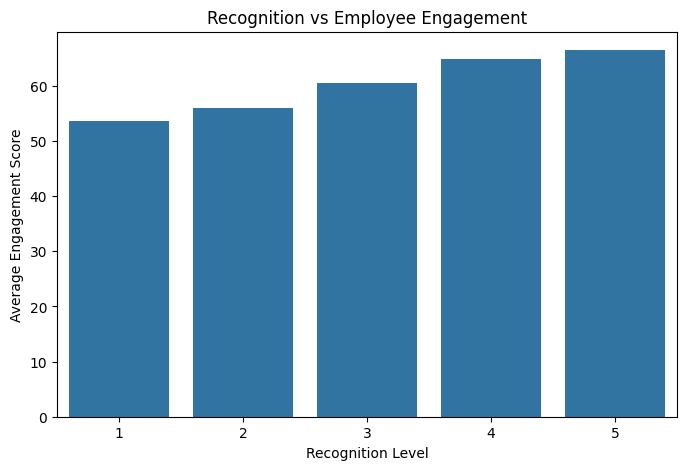

In [24]:
recognition_analysis = (
    df.groupby("Recognition")[
        "Engagement_Score"
    ].mean()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=recognition_analysis.index,
    y=recognition_analysis.values
)

plt.title("Recognition vs Employee Engagement")
plt.xlabel("Recognition Level")
plt.ylabel("Average Engagement Score")

plt.show()

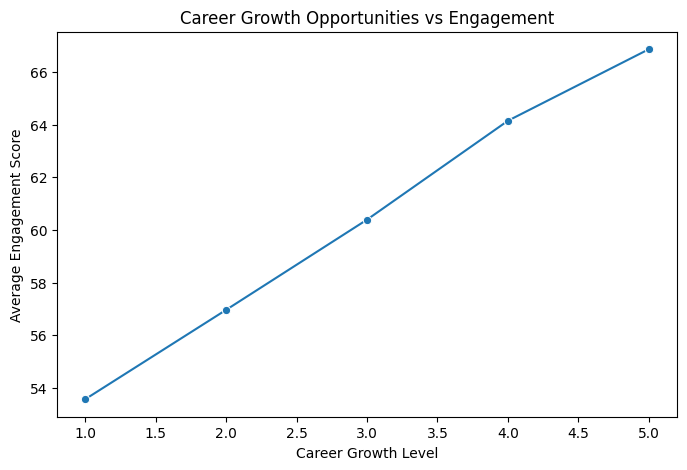

In [25]:
career_analysis = (
    df.groupby("Career_Growth")[
        "Engagement_Score"
    ].mean()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    x=career_analysis.index,
    y=career_analysis.values,
    marker="o"
)

plt.title("Career Growth Opportunities vs Engagement")
plt.xlabel("Career Growth Level")
plt.ylabel("Average Engagement Score")

plt.show()

In [26]:
burnout_hotspot = pd.pivot_table(
    df,
    values="Burnout_Score",
    index="Department",
    columns="Job_Level",
    aggfunc="mean"
)

print(
    burnout_hotspot.round(2)
)

Job_Level         Entry  Manager    Mid  Senior
Department                                     
Customer Support  87.14    80.55  84.44   85.60
Engineering       86.01    80.35  85.24   85.96
Finance           81.06    86.00  84.50   87.78
HR                87.42    86.81  81.50   82.18
Marketing         86.66    86.67  83.55   81.49
Sales             83.95    95.77  81.19   78.71


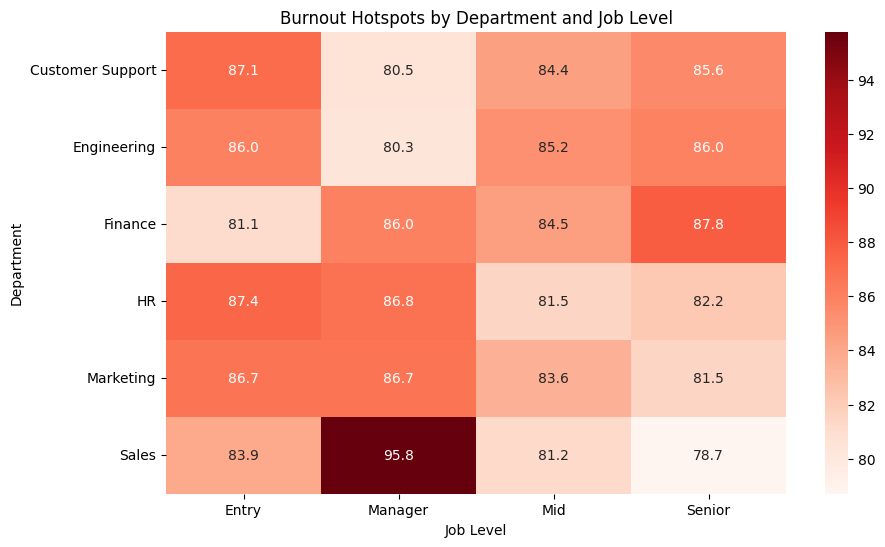

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    burnout_hotspot,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title(
    "Burnout Hotspots by Department and Job Level"
)

plt.xlabel("Job Level")
plt.ylabel("Department")

plt.show()

In [28]:
high_burnout = df[
    df["Burnout_Level"] == "High Burnout"
].sort_values(
    "Burnout_Score",
    ascending=False
)

print(
    "High Burnout Employees:",
    len(high_burnout)
)

high_burnout[
    [
        "Employee_ID",
        "Department",
        "Job_Level",
        "Working_Hours",
        "Overtime",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Burnout_Score",
        "Burnout_Level"
    ]
].head(20)

High Burnout Employees: 1300


,Employee_ID,Department,Job_Level,Working_Hours,Overtime,Job_Satisfaction,Work_Life_Balance,Burnout_Score,Burnout_Level
1499,2500,Customer Support,Mid,54,No,5,1,100.0,High Burnout
0,1001,HR,Entry,49,Yes,4,1,100.0,High Burnout
1,1002,Finance,Entry,40,No,3,2,100.0,High Burnout
1477,2478,Marketing,Manager,46,Yes,1,2,100.0,High Burnout
1476,2477,Finance,Senior,52,Yes,4,3,100.0,High Burnout
1474,2475,Customer Support,Entry,63,Yes,1,1,100.0,High Burnout
1471,2472,HR,Senior,58,Yes,4,1,100.0,High Burnout
1466,2467,Sales,Entry,43,Yes,5,1,100.0,High Burnout
1465,2466,Engineering,Senior,64,No,5,4,100.0,High Burnout
1463,2464,Customer Support,Manager,44,No,1,3,100.0,High Burnout


In [29]:
df["Employee_Status"] = np.select(
    [
        (df["Engagement_Score"] < 40) &
        (df["Burnout_Score"] >= 60),

        (df["Engagement_Score"] >= 70) &
        (df["Burnout_Score"] < 40),

        (df["Engagement_Score"] < 70) &
        (df["Burnout_Score"] >= 40)
    ],

    [
        "Critical Attention",
        "Healthy",
        "Needs Attention"
    ],

    default="Moderate"
)

df[
    [
        "Employee_ID",
        "Engagement_Score",
        "Burnout_Score",
        "Employee_Status"
    ]
].head(20)

,Employee_ID,Engagement_Score,Burnout_Score,Employee_Status
0,1001,63.33,100.00,Needs Attention
1,1002,80.00,100.00,Moderate
2,1003,63.33,89.00,Needs Attention
3,1004,56.67,92.33,Needs Attention
4,1005,43.33,100.00,Needs Attention
5,1006,63.33,76.33,Needs Attention
6,1007,63.33,100.00,Needs Attention
7,1008,56.67,97.67,Needs Attention
8,1009,56.67,100.00,Needs Attention
9,1010,83.33,94.33,Moderate


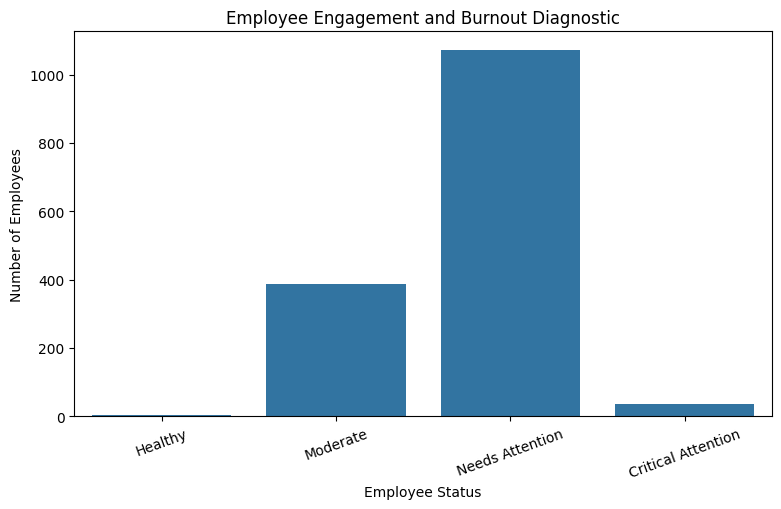

In [30]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Employee_Status",
    order=[
        "Healthy",
        "Moderate",
        "Needs Attention",
        "Critical Attention"
    ]
)

plt.title("Employee Engagement and Burnout Diagnostic")
plt.xlabel("Employee Status")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20)

plt.show()

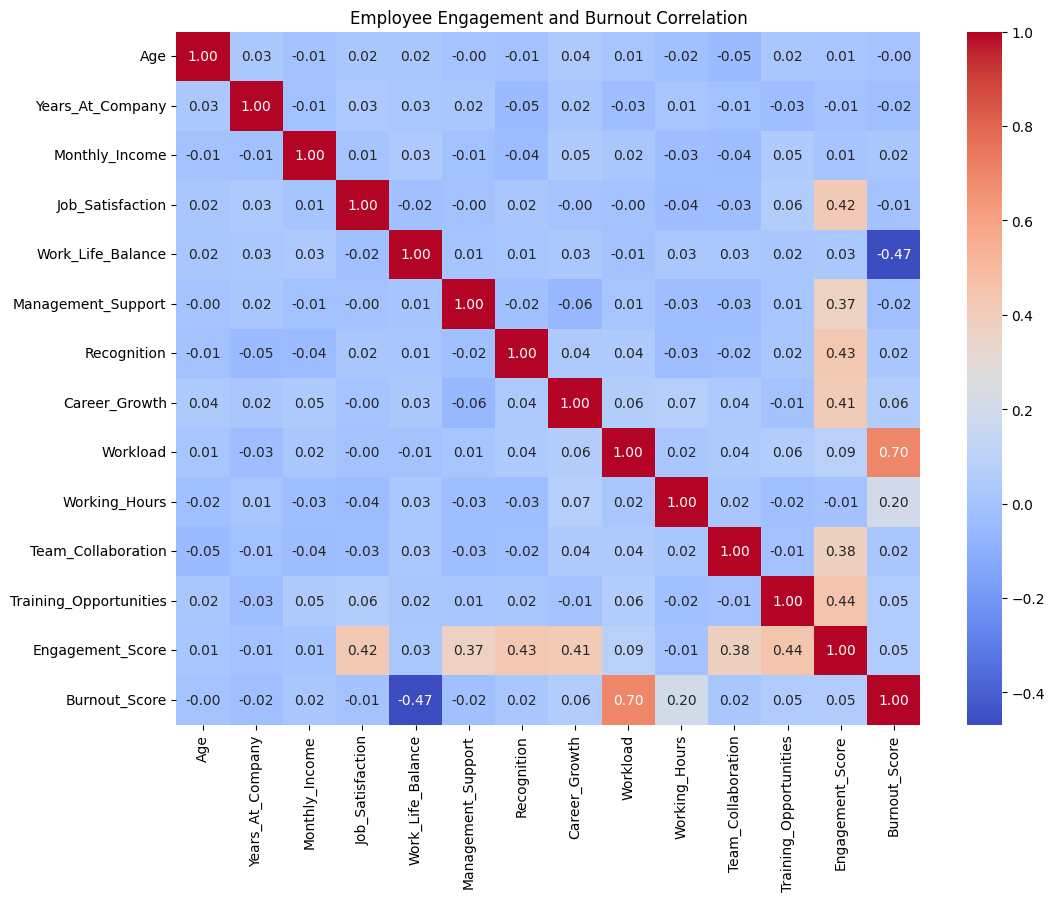

In [31]:
numeric_columns = [
    "Age",
    "Years_At_Company",
    "Monthly_Income",
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Management_Support",
    "Recognition",
    "Career_Growth",
    "Workload",
    "Working_Hours",
    "Team_Collaboration",
    "Training_Opportunities",
    "Engagement_Score",
    "Burnout_Score"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12,9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Employee Engagement and Burnout Correlation")

plt.show()

In [32]:
total_employees = len(df)

average_engagement = df[
    "Engagement_Score"
].mean()

average_burnout = df[
    "Burnout_Score"
].mean()

high_burnout_count = (
    df["Burnout_Level"] == "High Burnout"
).sum()

low_engagement_count = (
    df["Engagement_Level"] == "Low Engagement"
).sum()

critical_count = (
    df["Employee_Status"] == "Critical Attention"
).sum()

highest_burnout_department = (
    department_burnout.idxmax()
)

highest_burnout_value = (
    department_burnout.max()
)

highest_engagement_department = (
    department_engagement.idxmax()
)

highest_engagement_value = (
    department_engagement.max()
)

print("=" * 55)
print("EMPLOYEE ENGAGEMENT & BURNOUT SUMMARY")
print("=" * 55)

print("Total Employees:", total_employees)

print(
    "Average Engagement Score:",
    round(average_engagement, 2)
)

print(
    "Average Burnout Score:",
    round(average_burnout, 2)
)

print(
    "High Burnout Employees:",
    high_burnout_count
)

print(
    "Low Engagement Employees:",
    low_engagement_count
)

print(
    "Critical Attention Employees:",
    critical_count
)

print(
    "Highest Burnout Department:",
    highest_burnout_department,
    "(",
    round(highest_burnout_value, 2),
    ")"
)

print(
    "Highest Engagement Department:",
    highest_engagement_department,
    "(",
    round(highest_engagement_value, 2),
    ")"
)

print("=" * 55)

EMPLOYEE ENGAGEMENT & BURNOUT SUMMARY
Total Employees: 1500
Average Engagement Score: 60.4
Average Burnout Score: 84.35
High Burnout Employees: 1300
Low Engagement Employees: 80
Critical Attention Employees: 35
Highest Burnout Department: Customer Support ( 85.27 )
Highest Engagement Department: HR ( 61.4 )


In [33]:
df.to_csv(
    "Palo_Alto_Employee_Engagement_Burnout_Analysis.csv",
    index=False
)

high_burnout.to_csv(
    "High_Burnout_Employees.csv",
    index=False
)

print("Project files saved successfully!")

Project files saved successfully!


In [34]:
from google.colab import files

files.download(
    "Palo_Alto_Employee_Engagement_Burnout_Analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
files.download(
    "High_Burnout_Employees.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
print("""
====================================================
PROJECT CONCLUSION
====================================================

The Employee Engagement, Satisfaction and Burnout
Diagnostic Analysis project analyzes employee
engagement, satisfaction, workload and burnout
patterns.

A synthetic workforce dataset was created for
project demonstration because an official employee
dataset was not provided.

The analysis evaluates:

• Employee engagement levels
• Job satisfaction
• Work-life balance
• Management support
• Employee recognition
• Career growth opportunities
• Workload and working hours
• Overtime
• Burnout levels
• Department-wise engagement
• Department-wise burnout
• Burnout hotspots
• Critical employee groups

Employees were classified into Healthy, Moderate,
Needs Attention and Critical Attention categories
based on engagement and burnout scores.

The analysis can help HR teams identify areas where
employee experience may require attention and
support data-driven workforce improvement.

====================================================
PROJECT COMPLETED
====================================================
""")


PROJECT CONCLUSION

The Employee Engagement, Satisfaction and Burnout
Diagnostic Analysis project analyzes employee
engagement, satisfaction, workload and burnout
patterns.

A synthetic workforce dataset was created for
project demonstration because an official employee
dataset was not provided.

The analysis evaluates:

• Employee engagement levels
• Job satisfaction
• Work-life balance
• Management support
• Employee recognition
• Career growth opportunities
• Workload and working hours
• Overtime
• Burnout levels
• Department-wise engagement
• Department-wise burnout
• Burnout hotspots
• Critical employee groups

Employees were classified into Healthy, Moderate,
Needs Attention and Critical Attention categories
based on engagement and burnout scores.

The analysis can help HR teams identify areas where
employee experience may require attention and
support data-driven workforce improvement.

PROJECT COMPLETED

